In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
img = cv2.imread('asd.jpg')

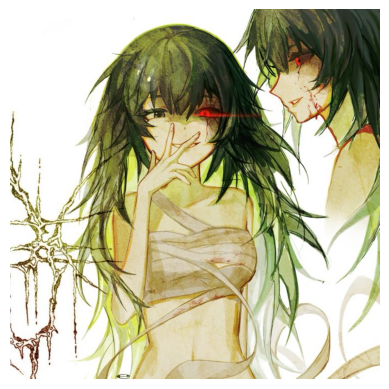

In [11]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# Размытие по гауссу

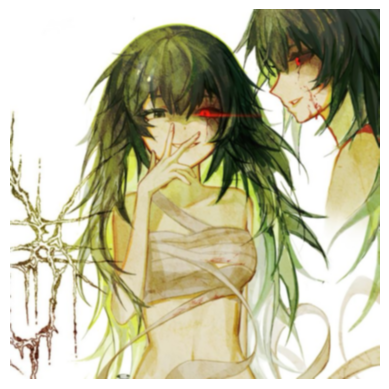

In [14]:
blurred_img = cv2.GaussianBlur(img, (5,5), sigmaX=1.5)

plt.imshow(blurred_img)
plt.axis('off')
plt.show()

# Повышение резкости

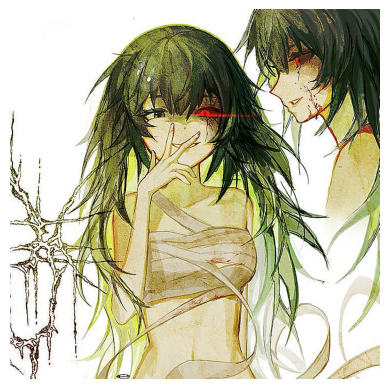

In [19]:
kernel = np.array([
    [0, -1, 0], 
    [-1, 5, -1], 
    [0, -1, 0]
]) 

sharpened_img = cv2.filter2D(img, -1, kernel)

plt.imshow(sharpened_img)
plt.axis('off')
plt.show()

# Оператор Собеля (выражение границ)

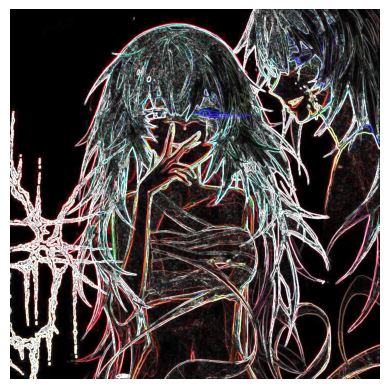

In [21]:
grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0)
grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1)

sobel_combined = cv2.magnitude(grad_x, grad_y)

sobel_combined = np.uint8(np.clip(sobel_combined, 0, 255))

sobel_rgb = cv2.cvtColor(sobel_combined, cv2.COLOR_BGR2RGB)

plt.imshow(sobel_rgb)
plt.axis('off')
plt.show()

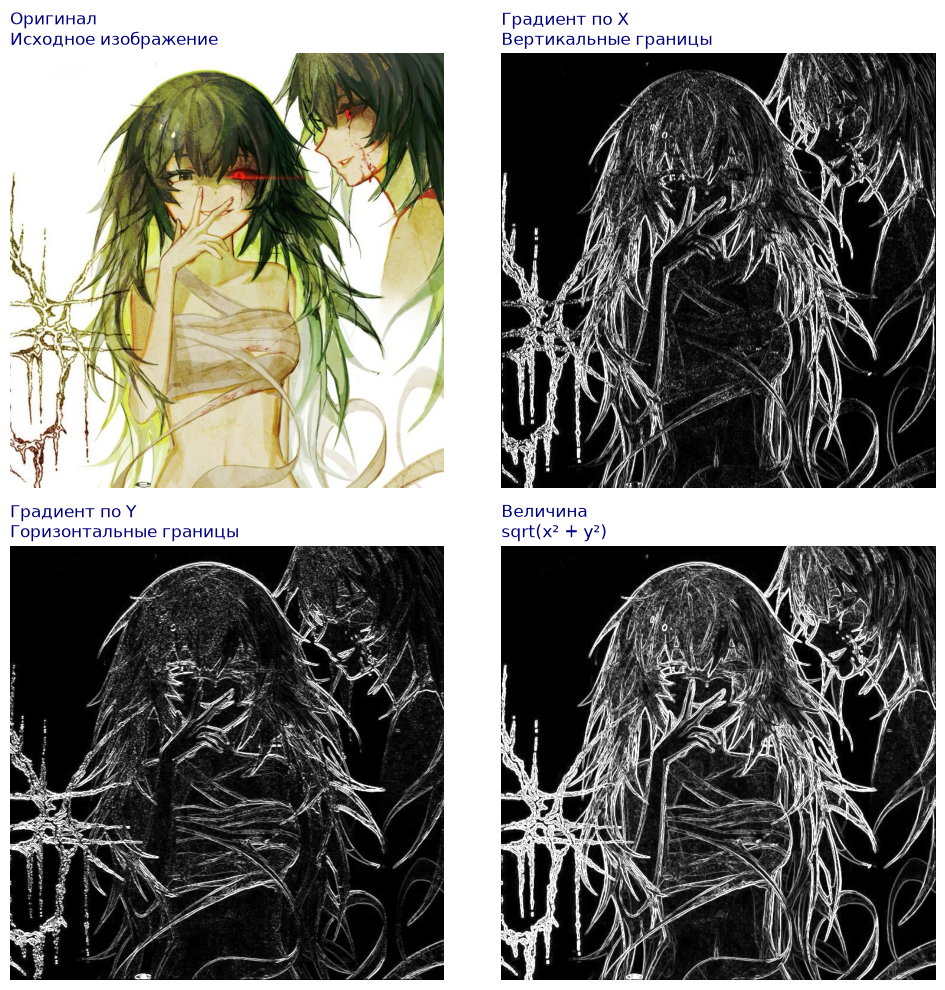

In [23]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Расчет градиентов
grad_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)

# Берем абсолютные значения для X и Y, чтобы убрать отрицательные величины
abs_grad_x = np.uint8(np.clip(np.abs(grad_x), 0, 255))
abs_grad_y = np.uint8(np.clip(np.abs(grad_y), 0, 255))

# Итоговая величина (корень из суммы квадратов)
sobel_combined = cv2.magnitude(grad_x, grad_y)
sobel_combined = np.uint8(np.clip(sobel_combined, 0, 255))

# 2. Создаем сетку из 2 строк и 2 столбцов
fig, axs = plt.subplots(2, 2, figsize=(10, 10))


axs[0, 0].imshow(img)
axs[0, 0].set_title('Оригинал\nИсходное изображение', fontsize=12, color='navy', loc='left')
axs[0, 0].axis('off')

# [0, 1] — Верхний правый угол (Градиент по X)
axs[0, 1].imshow(abs_grad_x, cmap='gray')
axs[0, 1].set_title('Градиент по X\nВертикальные границы', fontsize=12, color='navy', loc='left')
axs[0, 1].axis('off')

# [1, 0] — Нижний левый угол (Градиент по Y)
axs[1, 0].imshow(abs_grad_y, cmap='gray')
axs[1, 0].set_title('Градиент по Y\nГоризонтальные границы', fontsize=12, color='navy', loc='left')
axs[1, 0].axis('off')

# [1, 1] — Нижний правый угол (Величина)
axs[1, 1].imshow(sobel_combined, cmap='gray')
axs[1, 1].set_title('Величина\nsqrt(x² + y²)', fontsize=12, color='navy', loc='left')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()


# Оператор Кэнни

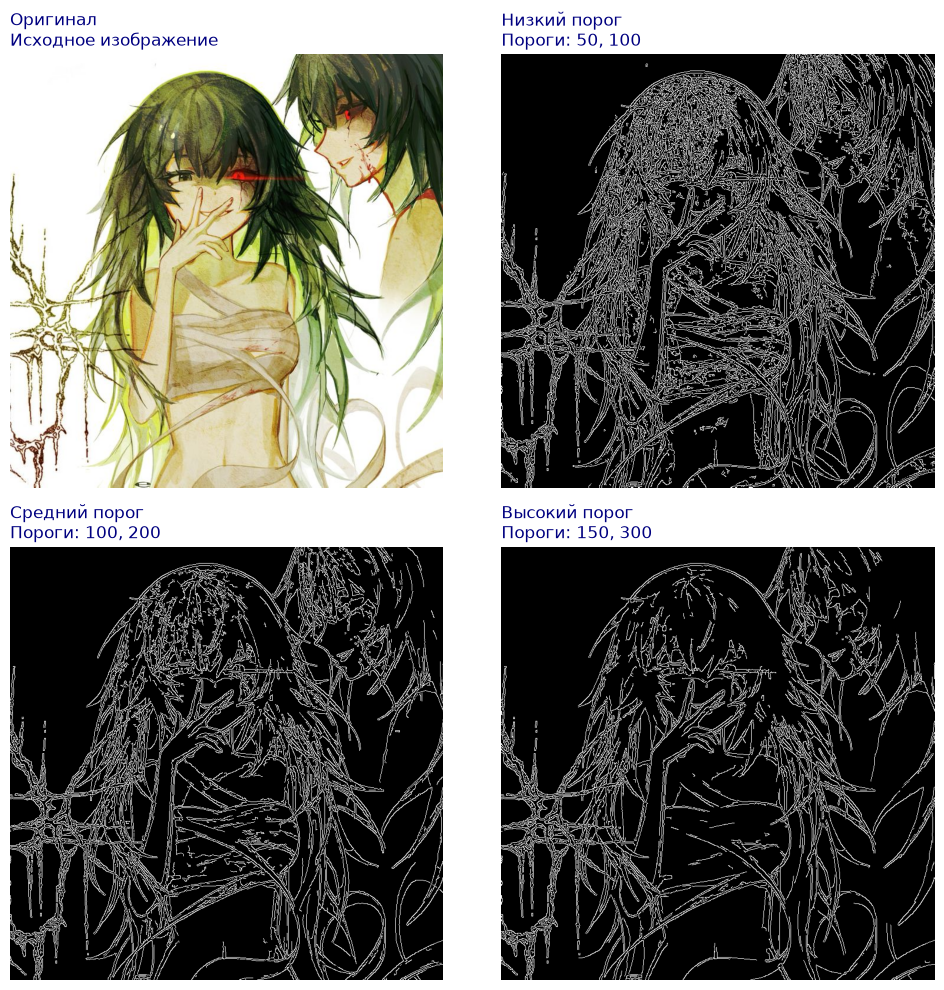

In [24]:
edges_low = cv2.Canny(img, 50, 100)
edges_middle = cv2.Canny(img, 100, 200)
edges_high = cv2.Canny(img, 150, 300)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(img)
axs[0, 0].set_title('Оригинал\nИсходное изображение', fontsize=12, color='navy', loc='left')
axs[0, 0].axis('off')

axs[0, 1].imshow(edges_low, cmap='gray')
axs[0, 1].set_title('Низкий порог\nПороги: 50, 100', fontsize=12, color='navy', loc='left')
axs[0, 1].axis('off')

axs[1, 0].imshow(edges_middle, cmap='gray')
axs[1, 0].set_title('Средний порог\nПороги: 100, 200', fontsize=12, color='navy', loc='left')
axs[1, 0].axis('off')

axs[1, 1].imshow(edges_high, cmap='gray')
axs[1, 1].set_title('Высокий порог\nПороги: 150, 300', fontsize=12, color='navy', loc='left')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Эрозия и дилатация

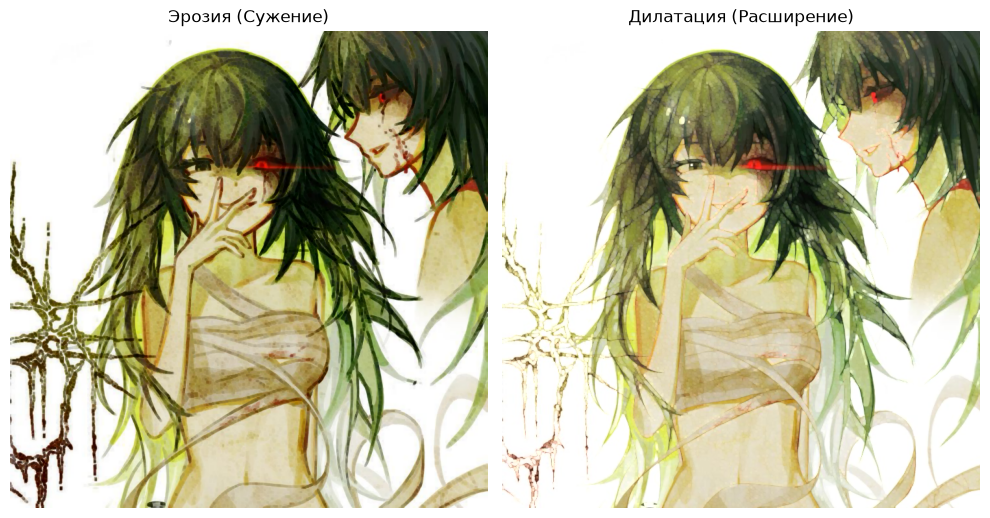

In [27]:
kernel = np.ones((3,3), np.uint8)

eroded = cv2.erode(img, kernel)

dilated = cv2.dilate(img, kernel)

fig, axes = plt.subplots(1, 2, figsize=(10, 10))

axes[0].imshow(eroded)
axes[0].set_title('Эрозия (Сужение)')
axes[0].axis('off')

axes[1].imshow(dilated)
axes[1].set_title('Дилатация (Расширение)')
axes[1].axis('off')


plt.tight_layout()
plt.show()

# Доработка изображения после Кэнни

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

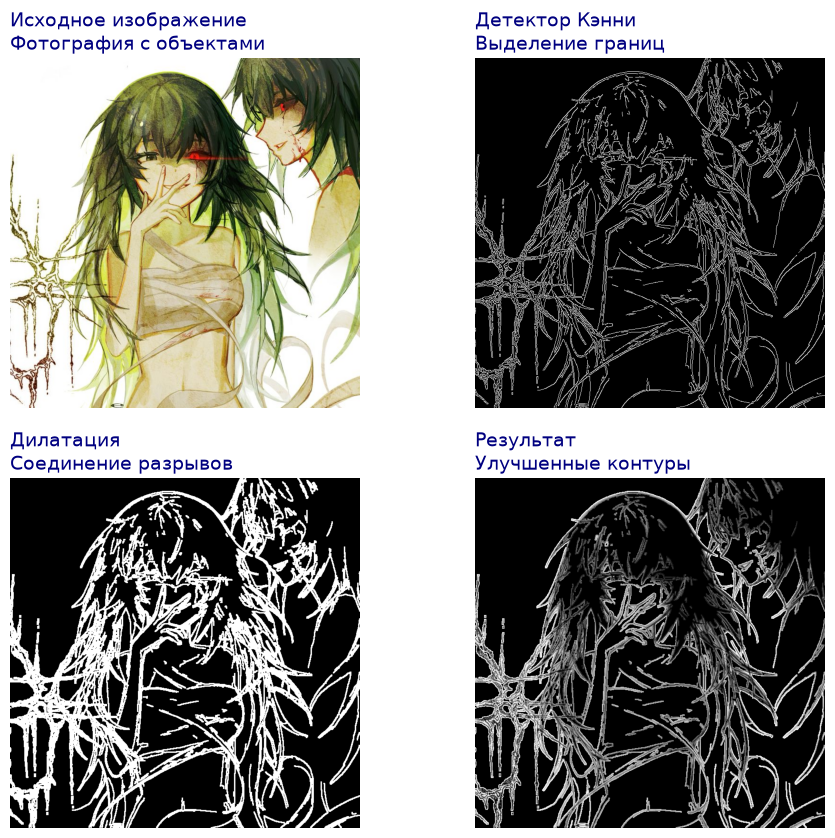

In [36]:
kernel_dil = np.ones((3,3), np.uint8)

edges_high = cv2.Canny(img, 150, 300)

dilated = cv2.dilate(edges_high, kernel_dil)

result = cv2.bitwise_and(gray_img, gray_img, mask=dilated)

fig, axs = plt.subplots(2, 2, figsize=(11, 10))

axs[0, 0].imshow(img)
axs[0, 0].set_title('Исходное изображение\nФотография с объектами', fontsize=14, color='navy', loc='left')
axs[0, 0].axis('off')

axs[0, 1].imshow(edges_high, cmap='gray')
axs[0, 1].set_title('Детектор Кэнни\nВыделение границ', fontsize=14, color='navy', loc='left')
axs[0, 1].axis('off')

axs[1, 0].imshow(dilated, cmap='gray')
axs[1, 0].set_title('Дилатация\nСоединение разрывов', fontsize=14, color='navy', loc='left')
axs[1, 0].axis('off')

axs[1, 1].imshow(result, cmap='gray')
axs[1, 1].set_title('Результат\nУлучшенные контуры', fontsize=14, color='navy', loc='left')
axs[1, 1].axis('off')